In [1]:
import sys

sys.path.append("../")
from explainerpfn.base import ExplainerPFN
from explainerpfn.train.synthetic_data import SyntheticDataGenerator
import torch
from torch import optim
from tqdm.auto import tqdm
import numpy as np

In [2]:
datasets = SyntheticDataGenerator(successor_as_target=True)
datasets.load_data(path="synthetic_data.pkl")

# Keep only datasets with 10 features or less - for testing purposes
desc = datasets.describe()
desc = desc[desc["n_features"] <= 11]
datasets_idxs = desc.index.tolist()

# Get iterator for datasets
data = list(zip(datasets.X_, datasets.y_pred_, datasets.explanations_))
data = [data[i] for i in datasets_idxs]

# Load model to train
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0, Loss: 0.367092
Epoch 1, Loss: -0.397624
Epoch 2, Loss: -0.763290
Epoch 3, Loss: -0.673468
Epoch 4, Loss: -0.683022
Epoch 5, Loss: -1.148137
Epoch 6, Loss: -0.477157
Epoch 7, Loss: -0.948138
Epoch 8, Loss: 0.345459
Epoch 9, Loss: -0.998562
Epoch 10, Loss: -1.123142
Epoch 11, Loss: -0.268870
Epoch 12, Loss: -1.241484
Epoch 13, Loss: -0.982333
Epoch 14, Loss: -1.355432
Epoch 15, Loss: 0.142392
Epoch 16, Loss: 0.231643
Epoch 17, Loss: 0.181876
Epoch 18, Loss: -1.276695
Epoch 19, Loss: -1.689638
Epoch 20, Loss: -1.070435
Epoch 21, Loss: -0.577027
Epoch 22, Loss: -0.927595
Epoch 23, Loss: -0.633410
Epoch 24, Loss: -0.975728
Epoch 25, Loss: 1.044193
Epoch 26, Loss: 1.926690
Epoch 27, Loss: 0.234158
Epoch 28, Loss: -1.364326
Epoch 29, Loss: -0.602290
Epoch 30, Loss: -0.843047
Epoch 31, Loss: -0.188195
Epoch 32, Loss: -1.339895
Epoch 33, Loss: -1.432287
Epoch 34, Loss: -1.323084
Epoch 35, Loss: -0.616570
Epoch 36, Loss: -0.193906
Epoch 37, Loss: -1.000348
Epoch 38, Loss: -1.846194
Epoc

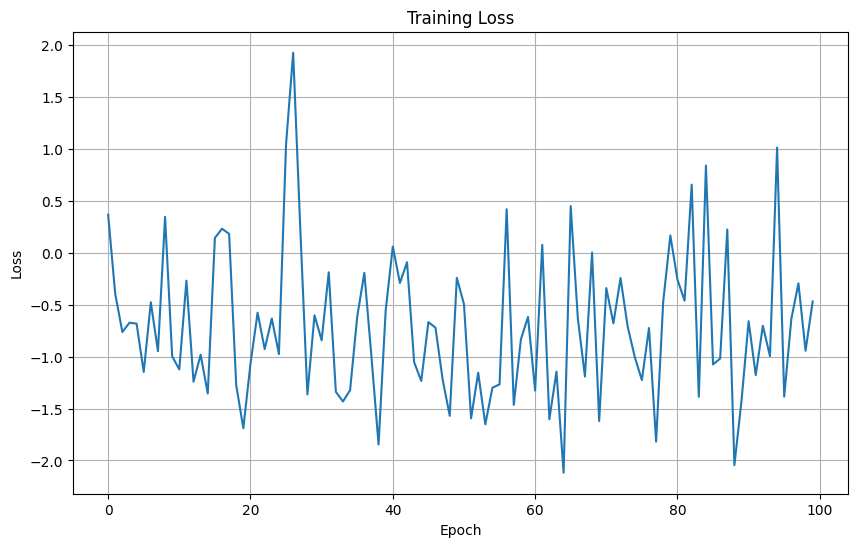

In [3]:
import matplotlib.pyplot as plt

random_state = None

# Create a new ExplainerPFN for the feature we want to finetune
xai = ExplainerPFN(
    fit_mode="low_memory",
    model_path="../../test_explainerpfn_model.ckp",
    random_state=random_state,
)
xai._initialize_model_variables()

# Setup optimizer - using Adam with a relatively small learning rate
# NOTE: Probably use lr=1e-5
optimizer = optim.Adam(xai.model_.parameters(), lr=1e-5)
rng = np.random.default_rng(random_state)

# Training parameters
num_epochs = 100
num_batches = 2

# Training loop
losses = []
for epoch in tqdm(range(num_epochs), desc="Epochs"):

    # Zero gradients once per epoch
    optimizer.zero_grad()

    # Shuffle indices for each epoch
    epoch_losses = []
    batch_idxs = rng.choice(np.arange(len(data)), size=num_batches, replace=False)

    # Collect logits and SHAP values from all batches
    all_logits = []
    all_shap_values = []
    all_batch_losses = []

    # Process all batches
    for batch_idx in batch_idxs:
        X_train, y_train, shap_train = data[batch_idx]

        indices = rng.permutation(len(X_train))
        feature_name = rng.choice(shap_train.columns[shap_train.nunique() > 1])
        feature_idx = shap_train.columns.get_loc(feature_name)

        # Get batch data
        X_batch = X_train.values[indices]
        y_batch = y_train[indices]
        shap_batch = shap_train.values[indices]  # Use iloc for proper indexing

        _xai = ExplainerPFN(fit_mode="low_memory", random_state=random_state)
        _xai.fit(X_batch, y_batch)
        _xai.model_ = xai.model_
        _xai.executor_.model = xai.model_
        _xai.executor_.use_torch_inference_mode(False)
        _xai.model_.train()

        # Get logits
        with torch.enable_grad():
            # xai.forward returns a tuple (first element are averaged logits across estimators)
            feature_logits = _xai.forward(
                X_batch, y_batch, feature_idx=feature_idx, only_return_standard_out=True
            )[0]

        # Collect logits and corresponding SHAP values for this batch
        all_logits.append(feature_logits)

        # Get the SHAP values for the selected feature
        batch_shap_values = shap_batch[:, feature_idx]
        batch_shap_tensor = torch.tensor(batch_shap_values, dtype=torch.float32).to(
            xai.device_
        )
        # all_shap_values.append(batch_shap_tensor)

        # Get the bardist loss for this batch
        batch_loss_per_sample = _xai.bardist_(feature_logits.T, batch_shap_tensor)
        all_batch_losses.append(batch_loss_per_sample)

    # Concatenate all batch results
    # logits = torch.cat(all_logits, dim=1)  # Concatenate along the sequence dimension
    # shap_tensor = torch.cat(all_shap_values, dim=0)  # Concatenate along batch dimension
    all_batch_losses_tensor = torch.cat(
        all_batch_losses, dim=0
    )  # Concatenate along batch dimension

    # Compute the loss for all batches combined
    # loss_per_sample = xai.bardist_(logits.T, shap_tensor)

    # Compute mean loss across all samples from all batches
    loss = all_batch_losses_tensor.mean()

    # Backpropagate once per epoch (after processing all batches)
    loss.backward()
    optimizer.step()

    # Record loss
    losses.append(loss.item())

    # Print progress
    # if epoch % 5 == 0 or epoch == num_epochs - 1:
    print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    # Save the finetuned model periodically
    # if epoch % 10 == 0 or epoch == num_epochs - 1:
    xai.save_foundation_model("../../test_explainerpfn_model.ckp")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

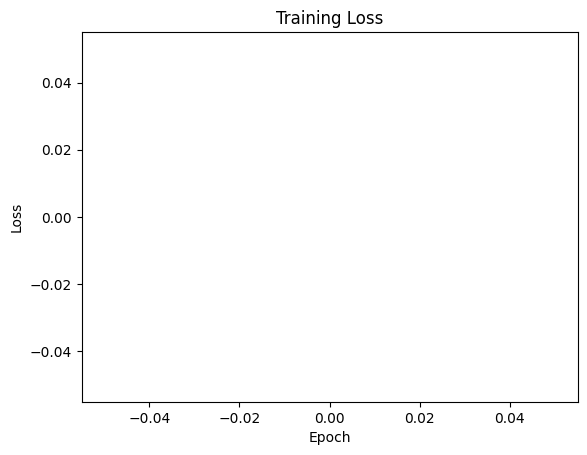

In [4]:
import matplotlib.pyplot as plt

losses = input()
epochs = [int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]
losses = [float(x.split(", Loss: ")[-1].strip()) for x in losses.split("Epoch") if x]

plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

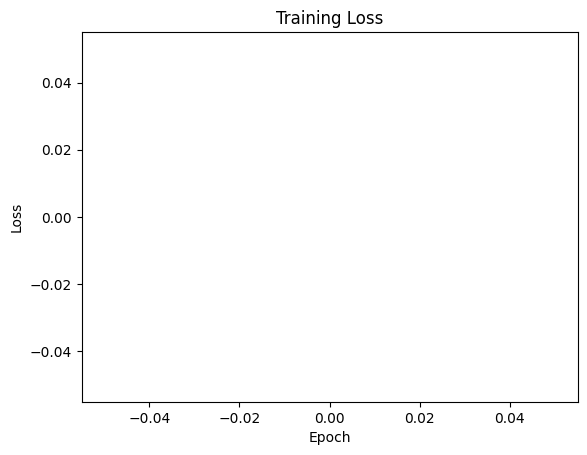

In [5]:
import matplotlib.pyplot as plt

losses = input()
epochs = [int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]
losses = [float(x.split(", Loss: ")[-1].strip()) for x in losses.split("Epoch") if x]

plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [6]:
[int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]

AttributeError: 'list' object has no attribute 'split'

In [ ]:
# _xai.bardist_(feature_logits.T, batch_shap_tensor)
feature_logits
batch_shap_tensor

tensor([ 0.0276, -0.0355,  0.0000,  0.0000])

In [ ]:
feature_logits.shape

torch.Size([5000, 391])